In [17]:
import torch
from torch import nn
from torch.utils.data import DataLoader

import torchvision
from torchvision.datasets import Food101
from torchvision.transforms import ToTensor
from torchvision import transforms

import pandas as pd 
import matplotlib.pyplot as plt 

print(f"Torch Version: {torch.__version__}")
print(f"Torchvision Version: {torchvision.__version__}")

Torch Version: 2.10.0+cu130
Torchvision Version: 0.25.0+cu130


In [18]:
import gc
torch.cuda.empty_cache()
gc.collect()

2032

In [19]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [20]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# Import/Explore Datasets

In [21]:
train_data = Food101(
    root="data", 
    split="train",
    transform=transform,
    target_transform= None,
    download=True
)

test_data = Food101(
    root="data",
    split="test",
    transform=transform,
    target_transform= None,
    download=True
)

In [22]:
print(f"Length of Test dataset: {len(train_data)}")
print(f"Length of Test dataset: {len(test_data)}")

Length of Test dataset: 75750
Length of Test dataset: 25250


In [23]:
class_names, labels = train_data.classes, train_data._labels


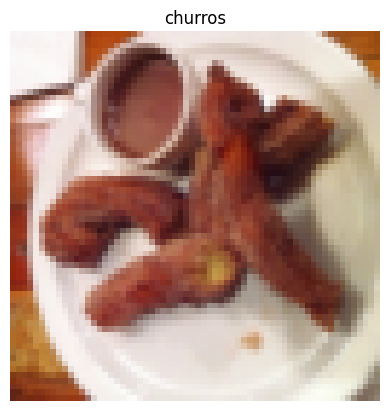

In [24]:
image, label = train_data[0]
plt.title(class_names[label])
plt.imshow(image.permute(2, 1, 0))
plt.axis(False)
plt.show()

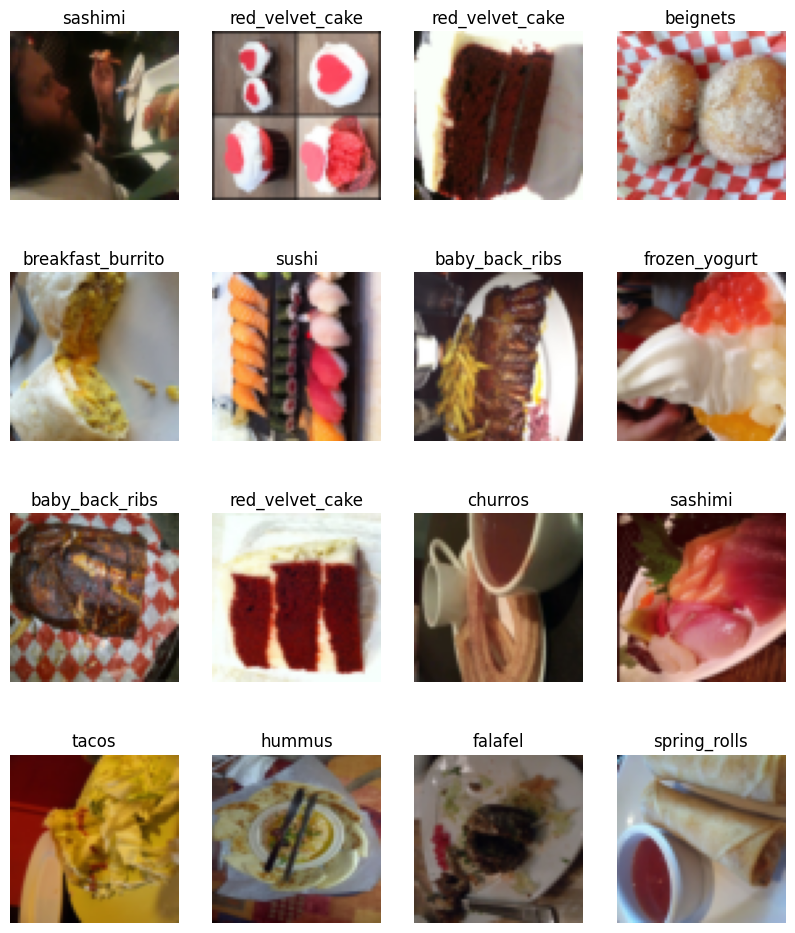

In [25]:
# Visualize More Data
nrows, ncols = 4, 4 
fig = plt.figure(figsize=(10, 12))
for i in range(1, nrows * ncols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    image, label = train_data[random_idx]
    fig.add_subplot(nrows, ncols, i)
    plt.title(class_names[label])
    plt.imshow(image.permute(2, 1, 0))
    plt.axis(False)

In [26]:
import os
print(os.cpu_count())

24


# DataLoaders

In [27]:
BATCH_SIZE = 128

train_dataloader = DataLoader(train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True,
                              num_workers=12,
                              pin_memory=True)

test_dataloader = DataLoader(test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False,
                             num_workers=12,
                             pin_memory=True)

print(f"Original Training Data: {len(train_data)}")
print(f"Original Testing Data: {len(test_data)}")
print(f"{len(train_dataloader)} train data on batches of {BATCH_SIZE}")
print(f"{len(test_dataloader)} test data on batches of {BATCH_SIZE}")

Original Training Data: 75750
Original Testing Data: 25250
592 train data on batches of 128
198 test data on batches of 128


# Create Models

In [28]:
class Food101V0(nn.Module):
    def __init__(self, 
                 input_units: int,
                 hidden_units: int,
                 output_units: int):
        super().__init__()
        self.stack_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_units,
                      out_features=hidden_units),
            nn.Linear(in_features=hidden_units,
                      out_features=hidden_units),
            nn.Linear(in_features=hidden_units,
                      out_features=output_units)
        )
    
    def forward(self, x: torch.Tensor):
        return self.stack_layer(x)

In [29]:
class Food101V1(nn.Module):
    def __init__(self, 
                 input_units: int,
                 hidden_units: int,
                 output_units: int):
        super().__init__()
        self.stack_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_units,
                      out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units,
                      out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units,
                      out_features=output_units),
            nn.ReLU()
        )
    
    def forward(self, x: torch.Tensor):
        return self.stack_layer(x)

In [30]:
class Food101V2(nn.Module):
    def __init__(self, 
                 input_units: int,
                 hidden_units: int,
                 output_units: int):
        super().__init__()

        # Resize layer — shrinks any image down to 64x64 automatically
        self.resize = nn.AdaptiveAvgPool2d((64, 64))

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=input_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU()
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      padding=1,
                      stride=1),
            nn.ReLU()
        )

        self.poolingLayer = nn.MaxPool2d(kernel_size=3, stride=1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 60 * 60,  # Update after checking shape
                      out_features=output_units)
        )

    def forward(self, x: torch.Tensor):
        x = self.resize(x)        # Resize first
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.poolingLayer(x)
        x = self.conv_block2(x)
        x = self.conv_block2(x)
        x = self.poolingLayer(x)
    
        x = self.classifier(x)
        return x

# Instantiate Models

In [31]:
model_0 = Food101V0(input_units=3 * 64 * 64,
                    hidden_units=512,
                    output_units=len(class_names)).to(device=device)

model_0

Food101V0(
  (stack_layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=12288, out_features=512, bias=True)
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): Linear(in_features=512, out_features=101, bias=True)
  )
)

In [32]:
model_1 = Food101V1(input_units=3*64*64,
                    hidden_units=512,
                    output_units=len(class_names)).to(device=device)

model_1

Food101V1(
  (stack_layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=12288, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=512, bias=True)
    (4): ReLU()
    (5): Linear(in_features=512, out_features=101, bias=True)
    (6): ReLU()
  )
)

In [33]:
model_2 = Food101V2(input_units=3,
                    hidden_units=64,
                    output_units=len(class_names)).to(device=device)

model_2

Food101V2(
  (resize): AdaptiveAvgPool2d(output_size=(64, 64))
  (conv_block1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
  )
  (conv_block2): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
  )
  (poolingLayer): MaxPool2d(kernel_size=3, stride=1, padding=0, dilation=1, ceil_mode=False)
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=230400, out_features=101, bias=True)
  )
)

# Create Training and Testing Functions

In [34]:
# CroossEntropyLoss -> Multiclass classification
loss_fn = nn.CrossEntropyLoss()

# SGD -> Stochastic gradient descent 
optimizer = torch.optim.Adam(model_0.parameters(),
                            lr = 0.001)

In [35]:
def accuracy_fn(y_true, y_pred):
    """
    Checks the accuracy of a model 

    Args:
        y_true (torch.Tensor): True labels for the data
        y_preds (torch.Tensor): Predicted labels for the data 

    Returns:
        [torch.float]: Accuracy of a between y_true and y_preds
    """

    correct_preds = torch.eq(y_true, y_pred).sum().item()

    acc =  (correct_preds/len(y_pred)) * 100
    return acc

In [36]:
# Train Function
def train_step(model: nn.Module, 
               dataloader: DataLoader, 
               loss_fn: nn.Module,
               accuracy_fn, 
               optimizer: torch.optim.Optimizer,
               device: torch.device = device):
    """
    Functioninzing the training process for an ai model 

    Args:
        model (torch.nn.Module): Takes the model as an argument for training
        dataloader (torch.utils.data.DataLoader): Takes dataloader for training 
        loss_fn (torch.nn.Module): Takes the loss function for the model as a parameter for loss calculation
        accuracy_fn (torch.optim.Optimizer): Takes the optimizer as an argument for nudging the models paramters 
        device (torch.device): Takes the current device at use for calculations

    Output:
        Training Loss | Training Accuracy
    """
    train_loss, train_acc = 0, 0
    model.to(device=device)
    model.train()

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Forward Pass
        y_pred = model(X)

        # Calculate loss
        loss = loss_fn(y_pred, y)
        acc = accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
        train_loss += loss
        train_acc += acc

        # Zero Step
        optimizer.zero_grad()

        # Loss Backward
        loss.backward()

        # Optim Step
        optimizer.step()
    
    # Calculate Loss/Accuracy Per Epoch
    train_loss /= len(dataloader)
    train_acc /= len(dataloader)

    # Print whats happening 
    print(f"Train Loss: {train_loss:.2f} | Train Accuracy: {train_acc:.2f}")

In [37]:
# Test Fucntion
def test_function(model: nn.Module, 
                  dataloader: DataLoader, 
                  loss_fn: nn.Module, 
                  accuracy_fn, 
                  device: torch.device = device):
    """
    Functioninzing the testing process for an ai model 

    Args:
        model (torch.nn.Module): Takes the model as an argument for testing
        dataloader (torch.utils.data.DataLoader): Takes dataloader for testing 
        loss_fn (torch.nn.Module): Takes the loss function for the model as a parameter for loss calculation
        accuracy_fn (torch.optim.Optimizer): Takes the optimizer as an argument for nudging the models paramters 
        device (torch.device): Takes the current device at use for calculations

    Output:
        Testing Loss | Testing Accuracy
    """
    model.to(device=device)

    test_loss, test_acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for batches, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            # Forward Pass
            y_pred = model(X)

            # Calculate Loss/Accuracy
            loss = loss_fn(y_pred, y)
            test_loss += loss
            accuracy = accuracy_fn(y_true=y, y_pred= y_pred.argmax(dim=1))
            test_acc += accuracy

        test_loss /= len(dataloader)
        test_acc /= len(dataloader)

        # Print whats happening 
        print(f"Test Loss: {test_loss} | Test Accuracy: {test_acc}")

# Create Timer Function

In [38]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float):
    """
    Prints the training time between a start and end time 

    Args:
        start (float): Start time in seconds
        end (float): End time in seconds
        device (torch.device): Device that the model was trained on 
    """
    total_time = end - start
    print(f"Train Time: {total_time:.3f} seconds")

# Train Models

In [39]:
# Train Model 0
from tqdm import tqdm
epochs = 3
start_time = timer()
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(model=model_0,
               dataloader=train_dataloader,
               loss_fn=loss_fn,
               accuracy_fn=accuracy_fn,
               optimizer=optimizer,
               device=device)

    test_function(model=model_0,
                  dataloader=test_dataloader,
                  loss_fn=loss_fn,
                  accuracy_fn=accuracy_fn,
                  device=device)

end_time = timer()
print_train_time(start=start_time, end=end_time)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------


  0%|          | 0/3 [00:29<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# Train Model 1
epochs = 3
start_time = timer()
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(model=model_1,
               dataloader=train_dataloader,
               loss_fn=loss_fn,
               accuracy_fn=accuracy_fn,
               optimizer=optimizer,
               device=device)

    test_function(model=model_1,
                  dataloader=test_dataloader,
                  loss_fn=loss_fn,
                  accuracy_fn=accuracy_fn,
                  device=device)

end_time = timer()
print_train_time(start=start_time, end=end_time)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train Loss: 4.62 | Train Accuracy: 0.96


 33%|███▎      | 1/3 [04:13<08:26, 253.05s/it]

Test Loss: 4.615407466888428 | Test Accuracy: 0.882120253164557
Epoch: 1
---------
Train Loss: 4.62 | Train Accuracy: 0.97


 67%|██████▋   | 2/3 [08:23<04:11, 251.51s/it]

Test Loss: 4.615407466888428 | Test Accuracy: 0.882120253164557
Epoch: 2
---------
Train Loss: 4.62 | Train Accuracy: 0.96


100%|██████████| 3/3 [12:32<00:00, 250.73s/it]

Test Loss: 4.615407466888428 | Test Accuracy: 0.882120253164557
Train Time: 752.208 seconds


In [40]:
# Train Model 2
import os

epochs = 3
start_time = timer()
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(model=model_2,
               dataloader=train_dataloader,
               loss_fn=loss_fn,
               accuracy_fn=accuracy_fn,
               optimizer=optimizer,
               device=device)

    test_function(model=model_2,
                  dataloader=test_dataloader,
                  loss_fn=loss_fn,
                  accuracy_fn=accuracy_fn,
                  device=device)
    os.environ['CUDA_LAUNCH_BLOCKING'] = '1'    

end_time = timer()
print_train_time(start=start_time, end=end_time)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train Loss: 4.62 | Train Accuracy: 1.18


 33%|███▎      | 1/3 [01:56<03:52, 116.27s/it]

Test Loss: 4.615175724029541 | Test Accuracy: 1.2192234848484849
Epoch: 1
---------
Train Loss: 4.62 | Train Accuracy: 1.18


 67%|██████▋   | 2/3 [03:54<01:57, 117.48s/it]

Test Loss: 4.615175724029541 | Test Accuracy: 1.2192234848484849
Epoch: 2
---------
Train Loss: 4.62 | Train Accuracy: 1.18


100%|██████████| 3/3 [05:50<00:00, 116.95s/it]

Test Loss: 4.615175724029541 | Test Accuracy: 1.2192234848484849
Train Time: 350.841 seconds


In [41]:
import torchvision.models as models

# Load pretrained ResNet50
model_transfer = models.resnet50(weights='DEFAULT')

# Freeze all layers
for param in model_transfer.parameters():
    param.requires_grad = False

# Replace final layer for 101 classes
model_transfer.fc = nn.Linear(in_features=2048, out_features=len(class_names))

# Move to GPU
model_transfer = model_transfer.to(device)

# Only train the final layer
optimizer = torch.optim.Adam(model_transfer.fc.parameters(), lr=0.001)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\ACER/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:07<00:00, 14.4MB/s]


In [42]:
# Train Model 3

epochs = 3
start_time = timer()
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(model=model_transfer,
               dataloader=train_dataloader,
               loss_fn=loss_fn,
               accuracy_fn=accuracy_fn,
               optimizer=optimizer,
               device=device)

    test_function(model=model_transfer,
                  dataloader=test_dataloader,
                  loss_fn=loss_fn,
                  accuracy_fn=accuracy_fn,
                  device=device)  

end_time = timer()
print_train_time(start=start_time, end=end_time)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train Loss: 3.68 | Train Accuracy: 18.74


 33%|███▎      | 1/3 [01:43<03:27, 103.74s/it]

Test Loss: 3.225430488586426 | Test Accuracy: 26.0836768419489
Epoch: 1
---------
Train Loss: 3.04 | Train Accuracy: 29.47


 67%|██████▋   | 2/3 [03:16<01:37, 97.08s/it] 

Test Loss: 3.1538212299346924 | Test Accuracy: 27.190331625074275
Epoch: 2
---------
Train Loss: 2.81 | Train Accuracy: 33.23


100%|██████████| 3/3 [05:03<00:00, 101.27s/it]

Test Loss: 3.1648950576782227 | Test Accuracy: 27.079851827094476
Train Time: 303.828 seconds


# Making Eval Metrics

In [44]:
def eval_model(model: nn.Module, 
               dataloader: DataLoader, 
               loss_fn: nn.Module,
               accuracy_fn, 
               device: torch.device = device):
    """
    Functioninzing the evaluation process for an ai model 

    Args:
        model (torch.nn.Module): Takes the model as an argument for evaluation
        dataloader (torch.utils.data.DataLoader): Takes dataloader for evaluation
        loss_fn (torch.nn.Module): Takes the loss function for the model as a parameter for loss calculation
        accuracy_fn (torch.optim.Optimizer): Takes the optimizer as an argument for nudging the models paramters
        device (torch.device): Takes the current device at use for calculations
        Output:
        Evaluation Loss | Evaluation Accuracy
    """
    model.to(device=device)
    eval_loss, eval_acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)

            # Forward Pass
            y_pred = model(X)

            # Calculate Loss/Accuracy
            loss = loss_fn(y_pred, y)
            eval_loss += loss
            acc = accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
            eval_acc += acc

        eval_loss /= len(dataloader)
        eval_acc /= len(dataloader)

        print(f"Eval Loss: {eval_loss} | Eval Accuracy: {eval_acc}")
        

In [ ]:
start_time = timer()
epochs = 3

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(model=model_transfer,
               dataloader=train_dataloader,
               loss_fn=loss_fn,
               accuracy_fn=accuracy_fn,
               optimizer=optimizer,
               device=device)

end_time = timer()
print_train_time(start=start_time, end=end_time)


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
